In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from statsmodels.tsa.stattools import coint, kpss
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

In [ ]:
### Variables ###

data_file = 'sp500_pricesto2019_snapshot.csv'
N_PRIN_COMPONENTS = 50
MAX_COMPONENTS = 30
# for clustering
MIN_SAMPLES_GRID = [3, 4, 5, 6, 7]
EPS_QUANTILE_GRID = [0.6, 0.65, 0.7, 0.75, 0.8, 0.85]
MIN_CLUSTERS = 7
CLUSTER_SIZE_LIMIT = 50


### Data collection ###

def get_sp500_historical():
    """
    Load the saved S&P 500 price snapshot and return it sorted by date and ticker.
    """
    data = pd.read_csv(data_file, index_col=0, parse_dates=True)
    data = data.sort_index().sort_index(axis=1)
    return data

def split_train_valid_test(data, split=[0.6, 0.2, 0.2]):
    """
    Split a price DataFrame into train, validation, and test segments.
    """
    n = len(data)
    train_end = int(n * split[0])
    valid_end = train_end + int(n * split[1])
    train = data.iloc[:train_end]
    valid = data.iloc[train_end:valid_end]
    test = data.iloc[valid_end:]
    return train, valid, test



### Decomposition ###

def get_pca_object(train):
    """
    Fit PCA on standardized daily returns from the training set.
    """

    returns = train.pct_change()
    returns = returns.iloc[1:, :].dropna(axis=1)

    scaler = StandardScaler()
    returns_scaled = pd.DataFrame(
        scaler.fit_transform(returns),
        index=returns.index,
        columns=returns.columns,
    )

    pca = PCA(n_components=N_PRIN_COMPONENTS, svd_solver="full")
    pca.fit(returns_scaled)
    return pca

def plot_component_variance(pca_object):
    """
    Plot explained variance and cumulative explained variance for the fitted PCA.
    """
    evr = pca_object.explained_variance_ratio_
    cum_evr = np.cumsum(evr)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(np.arange(1, len(evr)+1), evr, marker='o')
    plt.title("Explained Variance Ratio")
    plt.xlabel("Component")
    plt.ylabel("EVR")

    plt.subplot(1,2,2)
    plt.plot(np.arange(1, len(cum_evr)+1), cum_evr, marker='o')
    plt.title("Cumulative Explained Variance")
    plt.xlabel("Component")
    plt.ylabel("Cumulative EVR")
    plt.legend()
    plt.tight_layout()
    plt.show()




### Clustering ###

def cluster_by_loadings(pca_object):
    """
    Cluster stocks by their PCA loadings and return the filtered cluster labels.
    """
    X = pca_object.components_[:MAX_COMPONENTS].T

    min_samples_grid = MIN_SAMPLES_GRID
    eps_quantile_grid = EPS_QUANTILE_GRID

    results = []
    k_dist_by_ms = {}

    for ms in min_samples_grid:
        nn = NearestNeighbors(n_neighbors=ms).fit(X)
        distances, _ = nn.kneighbors(X)
        k_dist = np.sort(distances[:, -1])  # distance to ms-th nearest neighbor
        k_dist_by_ms[ms] = k_dist

        for q in eps_quantile_grid:
            ep = float(np.quantile(k_dist, q))
            labels = DBSCAN(min_samples=ms, eps=ep).fit(X).labels_

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            non_noise = labels != -1
            noise_ratio = 1 - non_noise.mean()

            # Need at least 2 non-noise clusters for silhouette and enough clusters overall.
            if n_clusters < MIN_CLUSTERS or n_clusters < 2 or non_noise.sum() < 3:
                continue

            score = silhouette_score(X[non_noise], labels[non_noise])
            results.append((score, n_clusters, noise_ratio, ms, q, ep))



    # Best by silhouette, then lower noise ratio.
    results = sorted(results, key=lambda x: (x[0], -x[2]), reverse=True)
    best = results[0]
    score, n_clusters, noise_ratio, best_ms, best_q, best_ep = best

    print(f"Best silhouette: {score:.4f}")
    print(f"Best min_samples: {best_ms}")
    print(f"Best eps_quantile: {best_q}")
    print(f"Best eps: {best_ep:.4f}")
    print(f"Clusters: {n_clusters}, noise_ratio: {noise_ratio:.2%}")

    # Plot only the best k-distance curve.
    best_k_dist = k_dist_by_ms[best_ms]
    plt.figure(figsize=(8, 4))
    plt.plot(best_k_dist, label=f"k-distance (min_samples={best_ms})")
    plt.axhline(best_ep, color="red", linestyle="--", label=f"best eps={best_ep:.4f}")
    plt.title(f"Best k-distance curve (min_samples={best_ms}, q={best_q})")
    plt.xlabel("Sorted points")
    plt.ylabel(f"Distance to {best_ms}-th nearest neighbor")
    plt.legend()
    plt.show()

    # final clustering with best params
    clustered = DBSCAN(min_samples=best_ms, eps=best_ep).fit(X).labels_
    pca_cols = pd.Index(pca_object.feature_names_in_)

    clustered_series = pd.Series(index=pca_cols, data=clustered.flatten())
    clustered_series = clustered_series[(clustered_series != -1)]
    counts = clustered_series.value_counts()
    counts = counts[(counts>1) & (counts<=CLUSTER_SIZE_LIMIT)]

    plt.barh(
        range(len(clustered_series.value_counts())),
        clustered_series.value_counts()
    )
    plt.title('Cluster Member Counts')
    plt.xlabel('Stocks in Cluster')
    plt.ylabel('Cluster Number')
    print ("Clusters formed: %d" % len(counts))
    print ("Pairs to evaluate: %d" % (counts*(counts-1)).sum())

    return clustered_series

def plot_sample_clusters(clustered_series, data):
    """
    Plot a few small clusters to visually inspect raw price behaviour.
    """
    counts = clustered_series.value_counts()
    counts = counts[(counts>1) & (counts<=CLUSTER_SIZE_LIMIT)]

    cluster_vis_list = list(counts[(counts < 20) & (counts > 1)].index)[::-1]

    for clust in cluster_vis_list[:3]:
        tickers = list(clustered_series[clustered_series == clust].index)

        data[tickers].plot(title='Raw Price Series for Cluster %d' % clust)



### Finding cointegrated pairs ###

def _direction_score_if_stationary(y, x, kpss_alpha=0.05, min_obs=60):
    """
    Return a score only if spread from y~x is stationary by KPSS.
    """
    if len(y) < min_obs:
        return None

    model = sm.OLS(y, sm.add_constant(x)).fit()
    alpha = float(model.params.iloc[0])
    beta = float(model.params.iloc[1])
    spread = y - (alpha + beta * x)

    try:
        _, kpss_pvalue, _, _ = kpss(spread, regression="c", nlags="auto")
    except Exception:
        return None

    if kpss_pvalue <= kpss_alpha:
        return None

    return 1.0 - float(kpss_pvalue)


def find_cointegrated_pairs(data, significance=0.05, kpss_alpha=0.05, min_obs=60):
    """
    Return pairs in the best direction if at least one direction's spread is stationary.
    """
    cols = data.columns
    n = len(cols)
    pairs = []


    for i in range(n):
        for j in range(i + 1, n):
            s1 = data[cols[i]]
            s2 = data[cols[j]]

            # Align once per pair; reuse for coint and both direction checks.
            aligned = pd.concat([s1, s2], axis=1).dropna()
            if len(aligned) < min_obs:
                continue

            y1 = aligned.iloc[:, 0]
            y2 = aligned.iloc[:, 1]

            _, coint_pvalue, _ = coint(y1, y2)
            if coint_pvalue >= significance:
                continue


            d1_score = _direction_score_if_stationary(
                y1, y2, kpss_alpha=kpss_alpha, min_obs=min_obs
            )
            d2_score = _direction_score_if_stationary(
                y2, y1, kpss_alpha=kpss_alpha, min_obs=min_obs
            )

            if d1_score is None and d2_score is None:
                continue


            if d2_score is None or (d1_score is not None and d1_score <= d2_score):
                pairs.append((cols[i], cols[j]))
            else:
                pairs.append((cols[j], cols[i]))

    return pairs

def find_all_cointegrated_pairs(clustered_series, train):
    """
    Search each cluster for cointegrated pairs and combine the results.
    """
    pairs = []
    counts = clustered_series.value_counts()
    counts = counts[(counts>1) & (counts<=CLUSTER_SIZE_LIMIT)]

    for which_clust in counts.index:
        tickers = clustered_series[clustered_series == which_clust].index
        x = train[tickers]
        keep = x.columns[x.isna().sum() <= 5]
        x = x[keep].interpolate(method="linear", limit_direction="both").dropna(axis=1)

        cluster_pairs = find_cointegrated_pairs(
            x,
            significance=0.05,
            kpss_alpha=0.05,
            min_obs=60,
        )
        for pair in cluster_pairs:
            pairs.append(pair)

    return pairs


### Creating signals and calculating pnl ###    


def calculate_spread_zscore(df, symbols, lookback=80, z_window=30, signal_lag=1):
    """
    Build rolling hedge-ratio spread and z-score for a pair.
    """
    y_symbol, x_symbol = symbols

    # Avoid in-place side effects.
    out = df[[y_symbol, x_symbol]].copy().dropna()

    min_needed = max(lookback, z_window)
    if len(out) < min_needed:
        out["alpha"] = np.nan
        out["hedge_ratio"] = np.nan
        out["spread"] = np.nan
        out["zscore"] = np.nan
        return out

    model = RollingOLS(
        endog=out[y_symbol],
        exog=sm.add_constant(out[x_symbol]),
        window=lookback,
    )
    results = model.fit(params_only=True)
    params = results.params.reindex(out.index)

    out["alpha"] = params["const"]
    out["hedge_ratio"] = params[x_symbol]
    out["spread"] = out[y_symbol] - out[x_symbol]

    # Use only prior info for signal generation.
    out["alpha"] = out["alpha"].shift(signal_lag)
    out["hedge_ratio"] = out["hedge_ratio"].shift(signal_lag)

    # Spread includes both intercept and slope.
    out["synthetic spread"] = out[y_symbol] - (out["alpha"] + out["hedge_ratio"] * out[x_symbol])

    spread_mean = out["synthetic spread"].rolling(window=z_window, min_periods=z_window).mean()
    spread_std = out["synthetic spread"].rolling(window=z_window, min_periods=z_window).std(ddof=0)


    spread_mean = spread_mean.shift(signal_lag)
    spread_std = spread_std.shift(signal_lag)

    out["zscore"] = (out["synthetic spread"] - spread_mean) / spread_std.replace(0.0, np.nan)

    return out


def create_long_short_market_signals(
    df,
    z_entry_threshold=2,
    z_exit_threshold=1,
    stop_loss_z= None
):
    """
    Build spread position targets from z-score and scale by hedge ratio

    Rules
    -----
    - Start flat.
    - If z <= -entry, buy spread (positive spread units).
    - If z >= +entry, sell spread (negative spread units).
    - If abs(z) < exit, close to flat.
    - Each full +1 increase in abs(z) beyond entry adds 1 spread unit.

    """
    out = df.copy()
    zscore_list = out["zscore"].to_numpy(dtype=float)

    spread_units = np.zeros(len(out), dtype=float)
    state = 0.0

    for i, zi in enumerate(zscore_list):
        if np.isnan(zi):
            state = 0.0
        else:
            abs_zi = abs(zi)

            if stop_loss_z is not None and state != 0.0 and abs_zi >= stop_loss_z:
                state = 0.0
            elif abs_zi < z_exit_threshold:
                state = 0.0
            elif zi <= -z_entry_threshold:
                state = np.floor(abs_zi - z_entry_threshold) + 1.0
            elif zi >= z_entry_threshold:
                state = -(np.floor(abs_zi - z_entry_threshold) + 1.0)
            # Otherwise keep previous state between exit and entry bands.

        spread_units[i] = state

    out["target_units"] = spread_units

    # Leg sizes for executable holdings in actual assets.
    hedge = out["hedge_ratio"].fillna(0.0)
    out["target_y_units"] = spread_units
    out["target_x_units"] = -spread_units * hedge

    return out



def calculate_pair_pnl(signal_df, symbols):
    """
    Compute pair PnL 

    Expects columns from create_long_short_market_signals:
    - target_y_units
    - target_x_units
    """
    y_col, x_col = symbols

    # Use prior holdings for mark-to-market PnL over t-1 -> t.
    signal_df["prev_y_units"] = signal_df["target_y_units"].shift(1).fillna(0.0)
    signal_df["prev_x_units"] = signal_df["target_x_units"].shift(1).fillna(0.0)

    signal_df["dy"] = signal_df[y_col].diff().fillna(0.0)
    signal_df["dx"] = signal_df[x_col].diff().fillna(0.0)

    signal_df["pnl_y"] = signal_df["prev_y_units"] * signal_df["dy"]
    signal_df["pnl_x"] = signal_df["prev_x_units"] * signal_df["dx"]

    signal_df["pnl"] = signal_df["pnl_y"] + signal_df["pnl_x"]
    signal_df["cumulative_pnl"] = signal_df["pnl"].cumsum()

    return signal_df



    return signal_df

# Data collection

In [273]:
data = get_sp500_historical()
display(data.head())
train, valid, test = split_train_valid_test(data)
print("Train:", train.index.min(), "to", train.index.max(), len(train), "days")
print("Valid:", valid.index.min(), "to", valid.index.max(), len(valid), "days")
print("Test:", test.index.min(), "to", test.index.max(), len(test), "days")


,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,62.300129,37.503742,65.326942,NaN,61.182667,24.904034,127.187782,224.570007,75.352371,33.040257,...,16.264624,97.230309,38.741745,50.001850,60.948055,57.200001,80.020287,93.622261,156.240005,79.459412
2019-01-03,60.005013,33.768066,63.174507,NaN,58.295197,24.514164,122.845314,215.699997,70.800705,32.895023,...,16.816105,96.289688,38.589104,49.234123,58.858704,52.419998,78.007523,91.928848,146.880005,76.712936
2019-01-04,62.082020,35.209621,65.209793,NaN,59.959003,25.094212,127.622055,226.190002,72.519630,33.653450,...,17.390234,100.173294,38.966713,51.049389,61.342075,58.180000,80.037781,95.068527,152.970001,79.722763
2019-01-07,63.400284,35.131237,66.161568,NaN,60.856926,25.037159,128.065308,229.259995,72.975677,33.822895,...,17.737736,101.952126,38.797981,51.314846,60.434872,60.720001,79.950256,95.105118,155.289993,80.202446
2019-01-08,64.329720,35.800949,66.469055,NaN,60.126270,25.132248,131.304062,232.679993,74.755981,34.452244,...,17.843500,105.146568,39.247910,51.687927,61.003033,63.119999,79.792740,92.972359,156.330002,81.396965


Train: 2019-01-02 00:00:00 to 2023-05-03 00:00:00 1092 days
Valid: 2023-05-04 00:00:00 to 2024-10-14 00:00:00 364 days
Test: 2024-10-15 00:00:00 to 2026-03-31 00:00:00 365 days


# Decomposition

C:\Users\ngche\AppData\Local\Temp\ipykernel_15556\3888004110.py:419: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


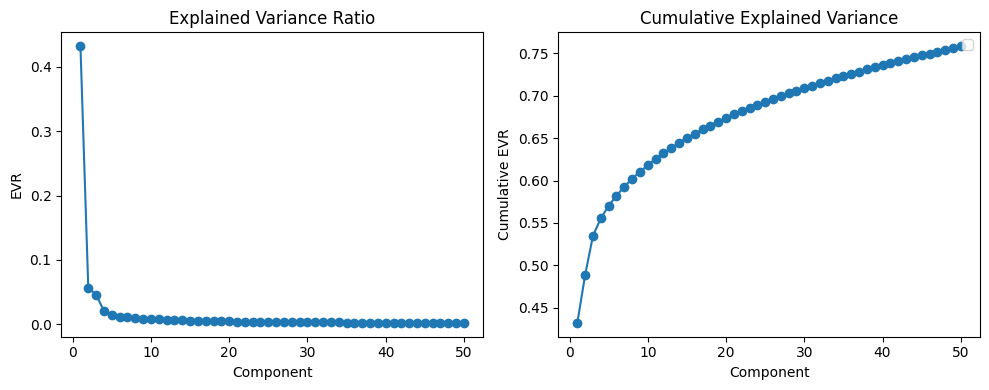

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'full'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [180]:
pca_object = get_pca_object(train)
plot_component_variance(pca_object)
pca_object

# Clustering

Best silhouette: 0.1630
Best min_samples: 3
Best eps_quantile: 0.6
Best eps: 0.1901
Clusters: 20, noise_ratio: 30.69%


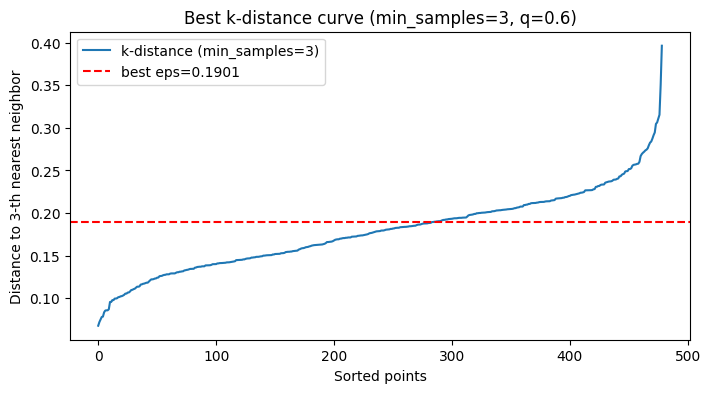

Clusters formed: 19
Pairs to evaluate: 2122


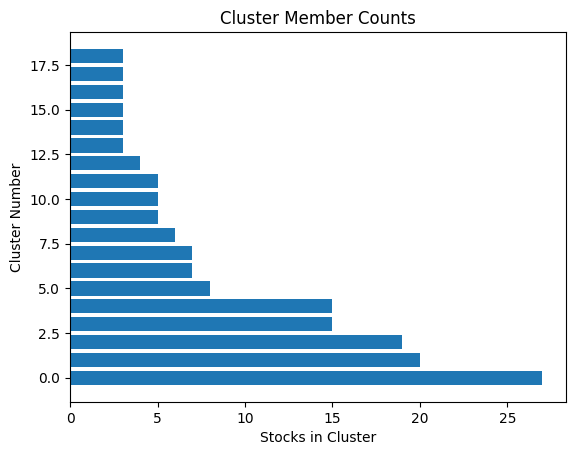

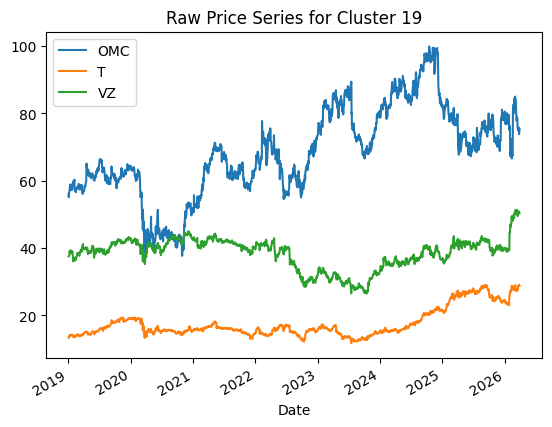

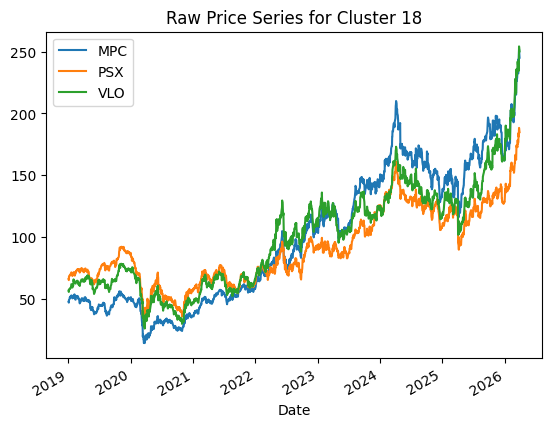

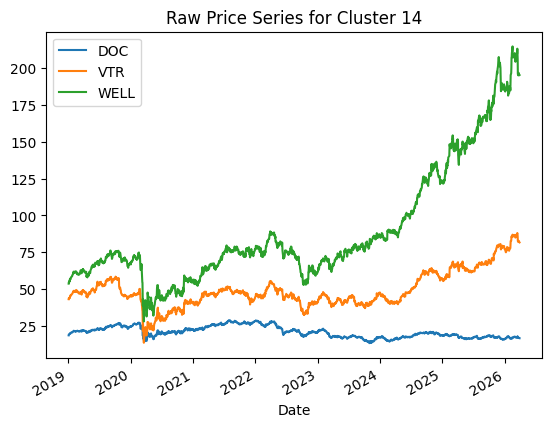

In [181]:
clustered_series = cluster_by_loadings(pca_object)
plot_sample_clusters(clustered_series, data)

# Finding cointegrated pairs

In [182]:
pairs = find_all_cointegrated_pairs(clustered_series, train)
pairs

C:\Users\ngche\AppData\Local\Temp\ipykernel_15556\3888004110.py:532: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  _, kpss_pvalue, _, _ = kpss(spread, regression="c", nlags="auto")
C:\Users\ngche\AppData\Local\Temp\ipykernel_15556\3888004110.py:532: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  _, kpss_pvalue, _, _ = kpss(spread, regression="c", nlags="auto")
C:\Users\ngche\AppData\Local\Temp\ipykernel_15556\3888004110.py:532: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  _, kpss_pvalue, _, _ = kpss(spread, regression="c", nlags="auto")
C:\Users\ngche\AppData\Local\Temp\ipykernel_15556\3888004110.py:532: InterpolationWarnin

[('AEP', 'EXC'),
 ('AEP', 'SRE'),
 ('ATO', 'ED'),
 ('PNW', 'AWK'),
 ('CMS', 'LNT'),
 ('DTE', 'DUK'),
 ('PEG', 'DTE'),
 ('ETR', 'EVRG'),
 ('ETR', 'EXC'),
 ('ETR', 'SRE'),
 ('EVRG', 'EXC'),
 ('PPL', 'SRE'),
 ('WEC', 'XEL'),
 ('RVTY', 'ABT'),
 ('ABT', 'WST'),
 ('ZTS', 'ABT'),
 ('EW', 'TECH'),
 ('EW', 'ZTS'),
 ('ISRG', 'IDXX'),
 ('RVTY', 'IQV'),
 ('WST', 'ZTS'),
 ('ARE', 'AMT'),
 ('FRT', 'SPG'),
 ('INVH', 'MAA'),
 ('CVX', 'COP'),
 ('FANG', 'EOG'),
 ('KMI', 'OKE'),
 ('KMI', 'SLB'),
 ('BKNG', 'MGM'),
 ('NCLH', 'CCL'),
 ('CL', 'MNST'),
 ('KMB', 'MNST'),
 ('CPAY', 'FIS'),
 ('V', 'MA'),
 ('AON', 'MRSH'),
 ('CHRW', 'JBHT'),
 ('CHRW', 'UPS'),
 ('UPS', 'JBHT'),
 ('LEN', 'DHI')]

In [183]:
len(pairs)

39

# Constructing signals, trades and PnL while tuning important parameters on validation set

In [ ]:
# Grid search to maximize Sharpe ratio: tune z_entry, z_exit, lookback, z_window, z_stop_loss
from itertools import product
initial_portfolio_value = 1_000_000
trade_fraction_range = [0.05, 0.07, 0.1]
best_params = None
best_sharpe = -np.inf
results = []
lookback_range = list(range(50, 121, 10)) 
z_window_range = list(range(20, 51, 5))    
z_entry_range = [1.5, 2.0, 2.5]      
z_exit_range = [0.5, 1.0]                  
z_stop_loss_range = [None, 3.0, 3.5, 4.0]  

for lookback, z_window, z_entry, z_exit, z_stop_loss, trade_fraction in product(lookback_range, z_window_range, z_entry_range, z_exit_range, z_stop_loss_range, trade_fraction_range):
    ann_return = np.nan
    ann_vol = np.nan
    sharpe = -np.inf
    all_pair_cum_pnl = {}
    for pair in pairs:
        spread_df = calculate_spread_zscore(valid, pair, lookback=lookback, z_window=z_window, signal_lag=1)
        signal_df = create_long_short_market_signals(spread_df, z_entry_threshold=z_entry, z_exit_threshold=z_exit, stop_loss_z  = z_stop_loss)
        pnl_df = calculate_pair_pnl(signal_df, pair)
        portfolio_value = initial_portfolio_value
        scaled_y_units = []
        scaled_x_units = []
        scale = 0
        for idx, (i, row) in enumerate(pnl_df.iterrows()):
            if idx == 0 or row['target_y_units'] != pnl_df['target_y_units'].iloc[idx-1]:
                notional = portfolio_value * trade_fraction * abs(row['target_y_units'])
                y_price = row[pair[0]]
                x_price = row[pair[1]]
                total_leg_notional = (abs(row["target_y_units"]) * abs(y_price)) + ((abs(row["target_x_units"]) * abs(x_price)))
                if total_leg_notional == 0:
                    scale = 0
                else:
                    scale = notional / total_leg_notional
            scaled_y_units.append(row['target_y_units'] * scale)
            scaled_x_units.append(row['target_x_units'] * scale)
        pnl_df['scaled_y_units'] = scaled_y_units
        pnl_df['scaled_x_units'] = scaled_x_units
        pnl_df['prev_y_units'] = pnl_df['scaled_y_units'].shift(1).fillna(0.0)
        pnl_df['prev_x_units'] = pnl_df['scaled_x_units'].shift(1).fillna(0.0)
        pnl_df['dy'] = pnl_df[pair[0]].diff().fillna(0.0)
        pnl_df['dx'] = pnl_df[pair[1]].diff().fillna(0.0)
        pnl_df['pnl_y'] = pnl_df['prev_y_units'] * pnl_df['dy']
        pnl_df['pnl_x'] = pnl_df['prev_x_units'] * pnl_df['dx']
        pnl_df['pnl'] = pnl_df['pnl_y'] + pnl_df['pnl_x']
        pnl_df['cumulative_pnl'] = pnl_df['pnl'].cumsum()
        key = f"{pair[0]}__{pair[1]}"
        all_pair_cum_pnl[key] = pnl_df['cumulative_pnl']
    all_pair_cum_pnl_df = pd.DataFrame(all_pair_cum_pnl).sort_index().ffill().fillna(0.0)
    combined_cumulative_pnl = all_pair_cum_pnl_df.sum(axis=1)
    portfolio_value_series = combined_cumulative_pnl + initial_portfolio_value

    # Only start from first trade
    if (portfolio_value_series != initial_portfolio_value).any():
        first_trade_idx = portfolio_value_series[portfolio_value_series != initial_portfolio_value].index[0]
        active_portfolio_value = portfolio_value_series.loc[first_trade_idx:]
        active_portfolio_returns = active_portfolio_value.pct_change().dropna()
        if len(active_portfolio_returns) > 1:
            ann_return = (1 + active_portfolio_returns).prod() ** (252 / len(active_portfolio_returns)) - 1
            ann_vol = active_portfolio_returns.std() * (252 ** 0.5)
            sharpe = ann_return / ann_vol if ann_vol > 0 else -np.inf
        else:
            sharpe = -np.inf
    else:
        sharpe = -np.inf

    results.append({'lookback': lookback, 'z_window': z_window, 'z_entry': z_entry, 'z_exit': z_exit, "z_stop_loss" : z_stop_loss, "trade_fraction" : trade_fraction, 'sharpe': sharpe, "returns" : ann_return, "vol" : ann_vol})
    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_params = (lookback, z_window, z_entry, z_exit, z_stop_loss, trade_fraction)

print(f"Best params: lookback={best_params[0]}, z_window={best_params[1]}, z_entry={best_params[2]}, z_exit={best_params[3]}, z_stop_loss={best_params[4]}, trade_fraction={best_params[5]}, Sharpe={best_sharpe:.2f}")
results_df = pd.DataFrame(results)
display(results_df.sort_values('sharpe', ascending=False).head(10))

Best params: lookback=110, z_window=45, z_entry=2.5, z_exit=0.5, z_stop_loss=3.5, trade_fraction=0.1, Sharpe=2.35


,lookback,z_window,z_entry,z_exit,z_stop_loss,trade_fraction,sharpe,returns,vol
3440,110,45,2.5,0.5,3.5,0.10,2.351035,0.276162,0.117464
3439,110,45,2.5,0.5,3.5,0.07,2.289673,0.191732,0.083738
3455,110,45,2.5,1.0,4.0,0.10,2.250099,0.258176,0.114740
3438,110,45,2.5,0.5,3.5,0.05,2.248580,0.136187,0.060566
3443,110,45,2.5,0.5,4.0,0.10,2.230971,0.265663,0.119080
3452,110,45,2.5,1.0,3.5,0.10,2.218907,0.252531,0.113809
3454,110,45,2.5,1.0,4.0,0.07,2.194360,0.179312,0.081715
2936,100,45,2.5,0.5,3.5,0.10,2.179995,0.196139,0.089972
3442,110,45,2.5,0.5,4.0,0.07,2.174536,0.184483,0.084838
3451,110,45,2.5,1.0,3.5,0.07,2.163652,0.175412,0.081072


In [239]:
best_params

(110, 45, 2.5, 0.5, 3.5, 0.1)

# Backtesting on test set with optimal important parameters derived from validation set

Date
2024-10-15    1.000000e+06
2024-10-16    1.000000e+06
2024-10-17    1.000000e+06
2024-10-18    1.000000e+06
2024-10-21    1.000000e+06
                  ...     
2026-03-24    1.086642e+06
2026-03-25    1.083787e+06
2026-03-26    1.082371e+06
2026-03-27    1.079985e+06
2026-03-30    1.081886e+06
Length: 364, dtype: float64

Test Set Annualized Return: 10.38%
Test Set Annualized Volatility: 7.19%
Test Set Sharpe Ratio: 1.44


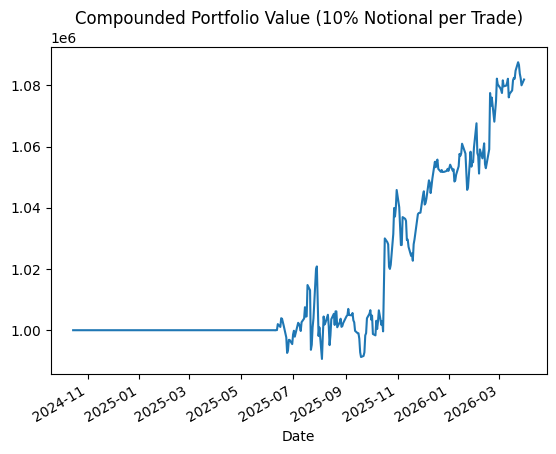

In [ ]:
# Unpack the best parameters
best_lookback, best_z_window, best_z_entry, best_z_exit, best_z_stop_loss, trade_fraction = best_params

# Backtest on the test set with optimal parameters
all_pair_cum_pnl_test = {}
for pair in pairs:
    spread_df = calculate_spread_zscore(test, pair, lookback=best_lookback, z_window=best_z_window, signal_lag=1)
    signal_df = create_long_short_market_signals(spread_df, z_entry_threshold=best_z_entry, z_exit_threshold=best_z_exit, stop_loss_z = best_z_stop_loss)
    pnl_df = calculate_pair_pnl(signal_df, pair)
    portfolio_value = initial_portfolio_value
    scaled_y_units = []
    scaled_x_units = []
    scale = 0
    for idx, (i, row) in enumerate(pnl_df.iterrows()):
        if idx == 0 or row['target_y_units'] != pnl_df['target_y_units'].iloc[idx-1]:
            notional = portfolio_value * trade_fraction * abs(row['target_y_units'])
            y_price = row[pair[0]]
            x_price = row[pair[1]]
            total_leg_notional = (abs(row["target_y_units"]) * abs(y_price)) + ((abs(row["target_x_units"]) * abs(x_price)))
            if total_leg_notional == 0:
                scale = 0
            else:
                scale = notional / total_leg_notional
        scaled_y_units.append(row['target_y_units'] * scale)
        scaled_x_units.append(row['target_x_units'] * scale)
    pnl_df['scaled_y_units'] = scaled_y_units
    pnl_df['scaled_x_units'] = scaled_x_units
    pnl_df['prev_y_units'] = pnl_df['scaled_y_units'].shift(1).fillna(0.0)
    pnl_df['prev_x_units'] = pnl_df['scaled_x_units'].shift(1).fillna(0.0)
    pnl_df['dy'] = pnl_df[pair[0]].diff().fillna(0.0)
    pnl_df['dx'] = pnl_df[pair[1]].diff().fillna(0.0)
    pnl_df['pnl_y'] = pnl_df['prev_y_units'] * pnl_df['dy']
    pnl_df['pnl_x'] = pnl_df['prev_x_units'] * pnl_df['dx']
    pnl_df['pnl'] = pnl_df['pnl_y'] + pnl_df['pnl_x']
    pnl_df['cumulative_pnl'] = pnl_df['pnl'].cumsum()
    key = f"{pair[0]}__{pair[1]}"
    all_pair_cum_pnl_test[key] = pnl_df['cumulative_pnl']

all_pair_cum_pnl_test_df = pd.DataFrame(all_pair_cum_pnl_test).sort_index().ffill().fillna(0.0)
combined_cumulative_pnl_test = all_pair_cum_pnl_test_df.sum(axis=1)
portfolio_value_series_test = combined_cumulative_pnl_test + initial_portfolio_value

display(portfolio_value_series_test)

# Visualisation of results

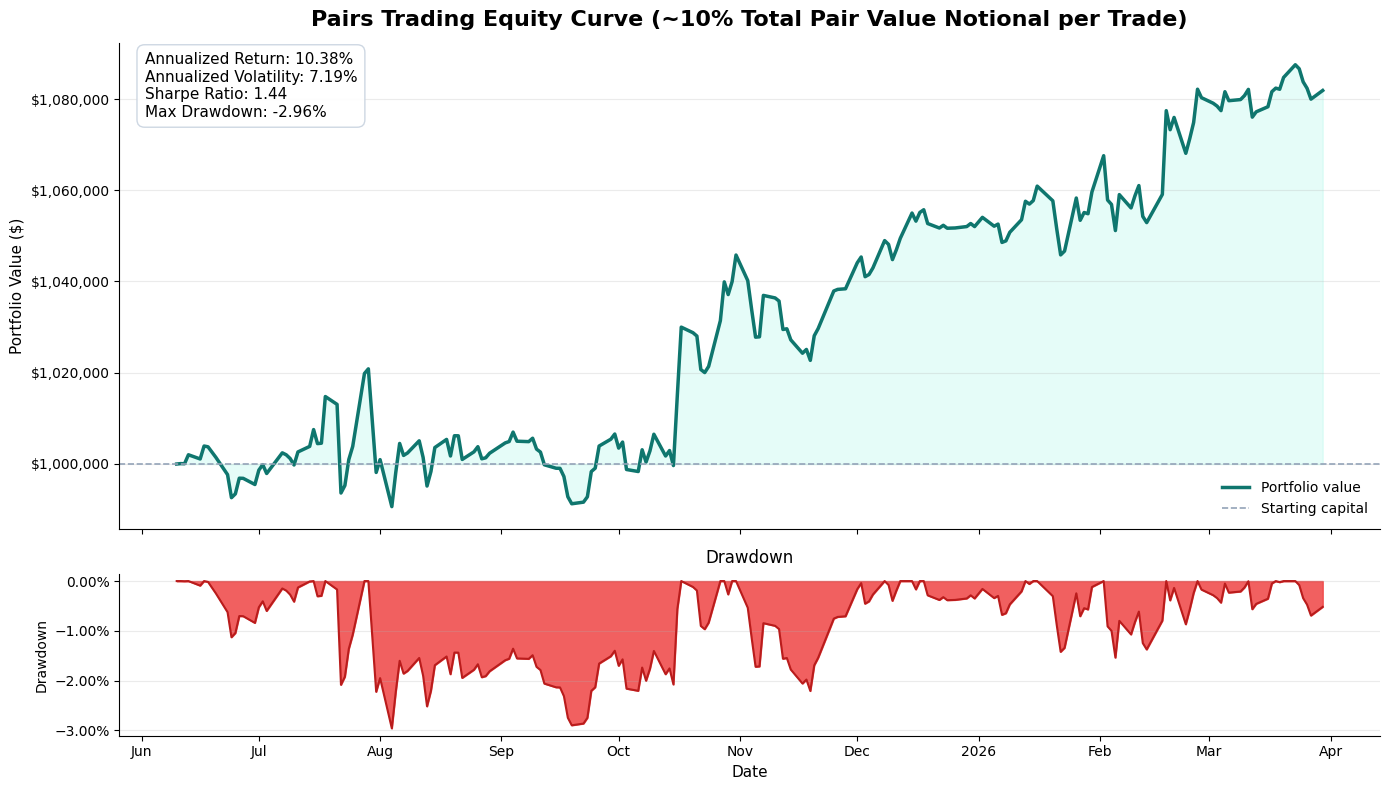

Test Set Annualized Return: 10.38%
Test Set Annualized Volatility: 7.19%
Test Set Sharpe Ratio: 1.44
Test Set Max Drawdown: -2.96%


In [257]:
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

first_trade_idx = portfolio_value_series_test[portfolio_value_series_test != initial_portfolio_value].index[0]
active_portfolio_value_test = portfolio_value_series_test.loc[first_trade_idx:]
active_portfolio_returns_test = active_portfolio_value_test.pct_change().dropna()

annualized_return_test = (1 + active_portfolio_returns_test).prod() ** (252 / len(active_portfolio_returns_test)) - 1
annualized_volatility_test = active_portfolio_returns_test.std() * (252 ** 0.5)
sharpe_ratio_test = annualized_return_test / annualized_volatility_test

running_peak = active_portfolio_value_test.cummax()
drawdown = active_portfolio_value_test / running_peak - 1
max_drawdown_test = drawdown.min()

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
 )
fig.patch.set_facecolor("white")

ax1.plot(
    active_portfolio_value_test.index,
    active_portfolio_value_test.values,
    color="#0f766e",
    linewidth=2.5,
    label="Portfolio value",
)
ax1.fill_between(
    active_portfolio_value_test.index,
    active_portfolio_value_test.values,
    active_portfolio_value_test.iloc[0],
    color="#99f6e4",
    alpha=0.25,
)
ax1.axhline(
    active_portfolio_value_test.iloc[0],
    color="#94a3b8",
    linestyle="--",
    linewidth=1.2,
    label="Starting capital",
)

stats_text = "\n".join([
    f"Annualized Return: {annualized_return_test:.2%}",
    f"Annualized Volatility: {annualized_volatility_test:.2%}",
    f"Sharpe Ratio: {sharpe_ratio_test:.2f}",
    f"Max Drawdown: {max_drawdown_test:.2%}",
])
ax1.text(
    0.02, 0.98, stats_text,
    transform=ax1.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox={"boxstyle": "round,pad=0.5", "facecolor": "white", "edgecolor": "#cbd5e1", "alpha": 0.95},
)

ax1.set_title(
    f"Pairs Trading Equity Curve (~{trade_fraction*100:.0f}% Total Pair Value Notional per Trade)",
    fontsize=16,
    fontweight="bold",
    pad=12,
)
ax1.set_ylabel("Portfolio Value ($)", fontsize=11)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax1.grid(True, axis="y", alpha=0.25)
ax1.legend(loc="lower right", frameon=False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.fill_between(
    drawdown.index,
    drawdown.values,
    0,
    color="#ef4444",
    alpha=0.85,
)
ax2.plot(drawdown.index, drawdown.values, color="#b91c1c", linewidth=1.5)
ax2.set_title("Drawdown", fontsize=12, pad=8)
ax2.set_ylabel("Drawdown", fontsize=10)
ax2.set_xlabel("Date", fontsize=11)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.grid(True, axis="y", alpha=0.25)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax2.xaxis.set_major_locator(locator)
ax2.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

print(f"Test Set Annualized Return: {annualized_return_test:.2%}")
print(f"Test Set Annualized Volatility: {annualized_volatility_test:.2%}")
print(f"Test Set Sharpe Ratio: {sharpe_ratio_test:.2f}")
print(f"Test Set Max Drawdown: {max_drawdown_test:.2%}")

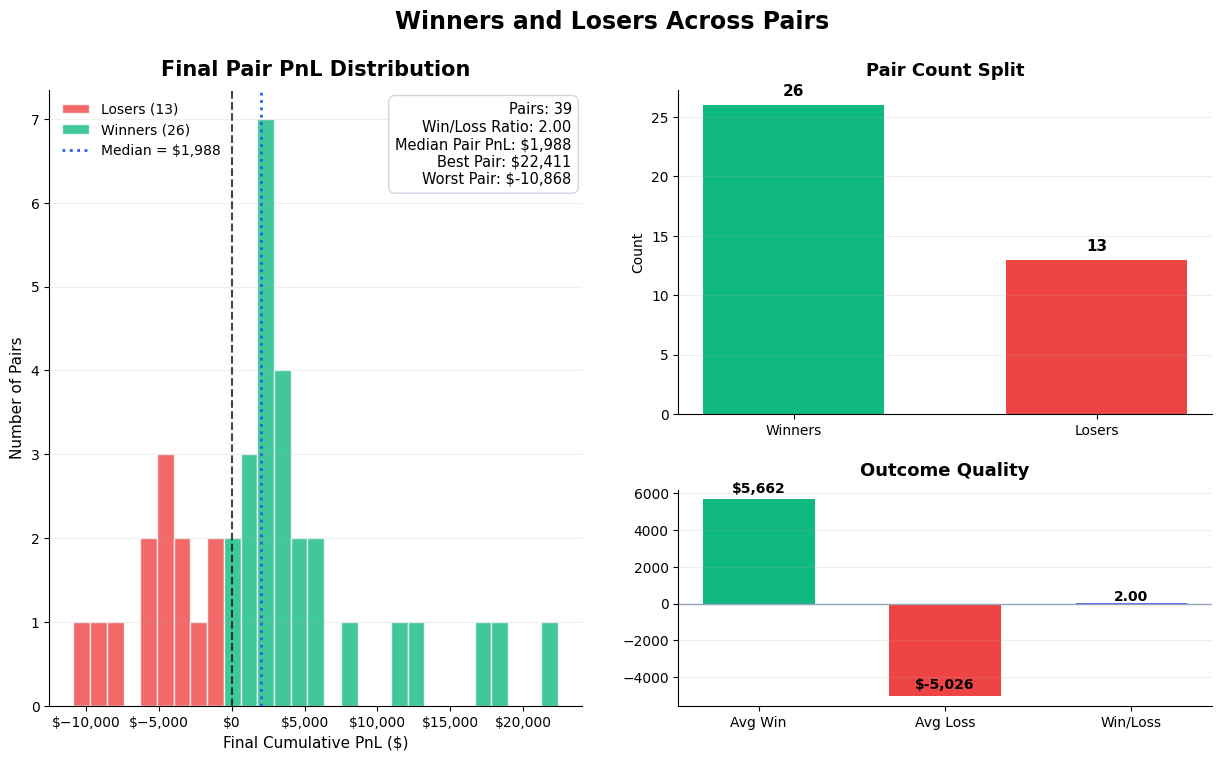

Win/Loss Ratio: 2.00  |  Wins: 26  Losses: 13
Average Winner: $5,662.50
Average Loser: $-5,026.09


In [259]:
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pair_final_pnl = pd.Series({
    pair_name: pair_pnl.iloc[-1]
    for pair_name, pair_pnl in all_pair_cum_pnl_test.items()
}).sort_values()

wins = pair_final_pnl[pair_final_pnl > 0]
losses = pair_final_pnl[pair_final_pnl <= 0]

n_wins = len(wins)
n_losses = len(losses)
win_loss_ratio = n_wins / n_losses if n_losses > 0 else float("inf")
avg_win = wins.mean() if n_wins > 0 else 0.0
avg_loss = losses.mean() if n_losses > 0 else 0.0
median_pnl = pair_final_pnl.median()

fig = plt.figure(figsize=(15, 8), facecolor="white")
gs = fig.add_gridspec(2, 2, height_ratios=[3, 2], hspace=0.28, wspace=0.18)

ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

bins = np.linspace(pair_final_pnl.min(), pair_final_pnl.max(), 30)
ax1.hist(losses, bins=bins, color="#ef4444", alpha=0.80, edgecolor="white", label=f"Losers ({n_losses})")
ax1.hist(wins, bins=bins, color="#10b981", alpha=0.80, edgecolor="white", label=f"Winners ({n_wins})")
ax1.axvline(0, color="#0f172a", linestyle="--", linewidth=1.5, alpha=0.8)
ax1.axvline(median_pnl, color="#2563eb", linestyle=":", linewidth=2, label=f"Median = ${median_pnl:,.0f}")
ax1.set_title("Final Pair PnL Distribution", fontsize=15, fontweight="bold", pad=10)
ax1.set_xlabel("Final Cumulative PnL ($)", fontsize=11)
ax1.set_ylabel("Number of Pairs", fontsize=11)
ax1.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax1.grid(True, axis="y", alpha=0.20)
ax1.legend(frameon=False, loc="upper left")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

summary_labels = ["Winners", "Losers"]
summary_counts = [n_wins, n_losses]
summary_colors = ["#10b981", "#ef4444"]
bars = ax2.bar(summary_labels, summary_counts, color=summary_colors, width=0.6)
ax2.set_title("Pair Count Split", fontsize=13, fontweight="bold", pad=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.grid(True, axis="y", alpha=0.20)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(summary_counts) * 0.02 if max(summary_counts) > 0 else 0.1,
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

metric_names = ["Avg Win", "Avg Loss", "Win/Loss"]
metric_values = [avg_win, avg_loss, win_loss_ratio if np.isfinite(win_loss_ratio) else np.nan]
metric_colors = ["#10b981", "#ef4444", "#6366f1"]
bars = ax3.bar(metric_names, metric_values, color=metric_colors, width=0.6)
ax3.set_title("Outcome Quality", fontsize=13, fontweight="bold", pad=10)
ax3.grid(True, axis="y", alpha=0.20)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.axhline(0, color="#94a3b8", linewidth=1)

for idx, bar in enumerate(bars):
    value = metric_values[idx]
    label = f"{value:.2f}" if metric_names[idx] == "Win/Loss" else f"${value:,.0f}"
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (max(metric_values[:2] + [0]) * 0.04 if idx < 2 else 0.02),
        label,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

stats_text = "\n".join([
    f"Pairs: {len(pair_final_pnl)}",
    f"Win/Loss Ratio: {win_loss_ratio:.2f}" if np.isfinite(win_loss_ratio) else "Win/Loss Ratio: inf",
    f"Median Pair PnL: ${median_pnl:,.0f}",
    f"Best Pair: ${pair_final_pnl.max():,.0f}",
    f"Worst Pair: ${pair_final_pnl.min():,.0f}",
])
ax1.text(
    0.98, 0.98, stats_text,
    transform=ax1.transAxes,
    ha="right",
    va="top",
    fontsize=10.5,
    bbox={"boxstyle": "round,pad=0.45", "facecolor": "white", "edgecolor": "#cbd5e1", "alpha": 0.95},
)

fig.suptitle("Winners and Losers Across Pairs", fontsize=17, fontweight="bold", y=0.98)
plt.show()

print(f"Win/Loss Ratio: {win_loss_ratio:.2f}  |  Wins: {n_wins}  Losses: {n_losses}")
print(f"Average Winner: ${avg_win:,.2f}")
print(f"Average Loser: ${avg_loss:,.2f}")